In [1]:
# Install required libraries
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.4 MB/s eta 0:00:00


In [2]:
# ============================================================
# Import Libraries
# ============================================================

import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ============================================================
# Load Dataset
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

print("Dataset Shape :", X.shape)

Dataset Shape : (569, 30)


In [4]:
# ============================================================
# Preprocessing
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [5]:
# ============================================================
# GT-PCA Feature Extraction
# ============================================================


n_components = 12

gt_pca = PCA(n_components=n_components)

X_gtpca = gt_pca.fit_transform(X_scaled)

print("Reduced Feature Shape :", X_gtpca.shape)

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_gtpca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Reduced Feature Shape : (569, 12)


In [6]:
# ============================================================
# SASEM Optimization
# ============================================================


def evaluate_solution(params):

    knn = KNeighborsClassifier(
        n_neighbors=params["knn_neighbors"]
    )

    lr = LogisticRegression(
        C=params["lr_c"],
        max_iter=500
    )

    gb = GradientBoostingClassifier(
        n_estimators=params["gb_estimators"],
        learning_rate=params["gb_lr"]
    )

    rf = RandomForestClassifier(
        n_estimators=params["rf_estimators"],
        max_depth=params["rf_depth"],
        random_state=42
    )

    ffnn = MLPClassifier(
        hidden_layer_sizes=(params["ffnn_hidden"],),
        max_iter=500,
        random_state=42
    )

    ensemble = VotingClassifier(
        estimators=[
            ("knn", knn),
            ("lr", lr),
            ("gb", gb),
            ("rf", rf),
            ("ffnn", ffnn)
        ],
        voting='soft'
    )

    scores = cross_val_score(
        ensemble,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    return scores.mean()


In [7]:
# ============================================================
# Initial Parameters
# ============================================================

current_solution = {
    "knn_neighbors": 5,
    "lr_c": 1.0,
    "gb_estimators": 100,
    "gb_lr": 0.1,
    "rf_estimators": 100,
    "rf_depth": 5,
    "ffnn_hidden": 50
}

current_score = evaluate_solution(current_solution)

best_solution = current_solution.copy()
best_score = current_score

In [8]:
# ============================================================
# Simulated Annealing Parameters
# ============================================================

temperature = 10
cooling_rate = 0.90
iterations = 20

# ============================================================
# SASEM Main Loop
# ============================================================

for iteration in range(iterations):

    new_solution = {
        "knn_neighbors": random.randint(3, 15),
        "lr_c": random.uniform(0.01, 5),
        "gb_estimators": random.randint(50, 200),
        "gb_lr": random.uniform(0.01, 0.3),
        "rf_estimators": random.randint(50, 200),
        "rf_depth": random.randint(3, 15),
        "ffnn_hidden": random.randint(20, 150)
    }

    new_score = evaluate_solution(new_solution)

    delta = new_score - current_score

    # Acceptance Probability
    if delta > 0:
        current_solution = new_solution
        current_score = new_score

    else:
        probability = np.exp(delta / temperature)

        if random.random() < probability:
            current_solution = new_solution
            current_score = new_score

    # Update Best Solution
    if current_score > best_score:
        best_solution = current_solution.copy()
        best_score = current_score

    # Cooling
    temperature *= cooling_rate

    print(f"Iteration {iteration+1}")
    print("Best Accuracy :", best_score)
    print("----------------------------------")


Iteration 1
Best Accuracy : 0.9692307692307691
----------------------------------
Iteration 2
Best Accuracy : 0.9714285714285713
----------------------------------
Iteration 3
Best Accuracy : 0.9714285714285713
----------------------------------
Iteration 4
Best Accuracy : 0.9736263736263737
----------------------------------
Iteration 5
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 6
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 7
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 8
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 9
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 10
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 11
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 12
Best Accuracy : 0.9758241758241759
----------------------------------
Iteration 13


In [9]:
# ============================================================
# Best Parameters
# ============================================================

print("\nBest Parameters")
print(best_solution)

# ============================================================
# Final Ensemble Model
# ============================================================

knn = KNeighborsClassifier(
    n_neighbors=best_solution["knn_neighbors"]
)

lr = LogisticRegression(
    C=best_solution["lr_c"],
    max_iter=500
)

gb = GradientBoostingClassifier(
    n_estimators=best_solution["gb_estimators"],
    learning_rate=best_solution["gb_lr"]
)

rf = RandomForestClassifier(
    n_estimators=best_solution["rf_estimators"],
    max_depth=best_solution["rf_depth"],
    random_state=42
)

ffnn = MLPClassifier(
    hidden_layer_sizes=(best_solution["ffnn_hidden"],),
    max_iter=500,
    random_state=42
)

soft_voting_model = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("lr", lr),
        ("gb", gb),
        ("rf", rf),
        ("ffnn", ffnn)
    ],
    voting='soft'
)


Best Parameters
{'knn_neighbors': 3, 'lr_c': 0.3293303512268155, 'gb_estimators': 88, 'gb_lr': 0.2034231706875727, 'rf_estimators': 97, 'rf_depth': 6, 'ffnn_hidden': 61}



Performance Metrics
Accuracy  : 95.61 %
Precision : 97.18 %
Recall    : 95.83 %
F1 Score  : 96.5 %
AUC ROC   : 0.99

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



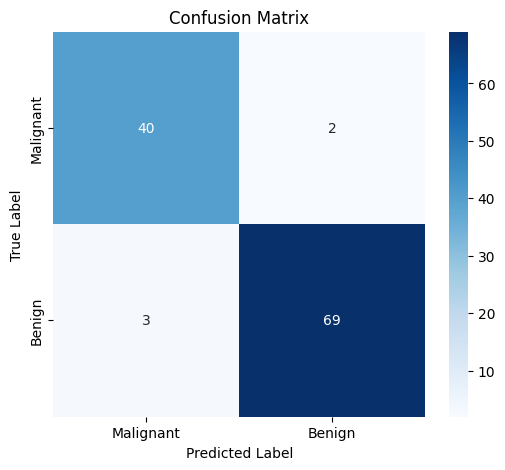

In [10]:
# ============================================================
# Training
# ============================================================

soft_voting_model.fit(X_train, y_train)

# ============================================================
# Prediction
# ============================================================

y_pred = soft_voting_model.predict(X_test)

y_prob = soft_voting_model.predict_proba(X_test)[:,1]

# ============================================================
# Performance Metrics
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n==============================")
print("Performance Metrics")
print("==============================")

print("Accuracy  :", round(accuracy*100,2), "%")
print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")
print("AUC ROC   :", round(auc,2))

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant','Benign'],
    yticklabels=['Malignant','Benign']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

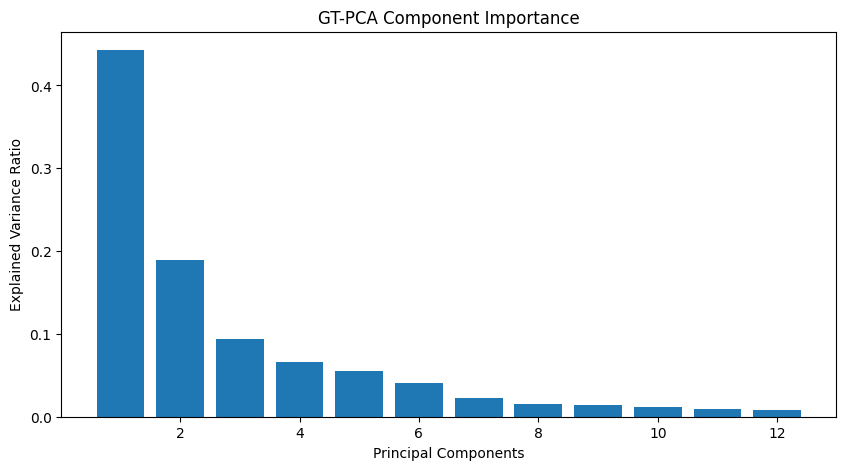

In [11]:
# ============================================================
# Feature Importance Visualization
# ============================================================

explained_variance = gt_pca.explained_variance_ratio_

plt.figure(figsize=(10,5))

plt.bar(
    range(1, n_components+1),
    explained_variance
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("GT-PCA Component Importance")

plt.show()


In [12]:
# ============================================================
# Runtime and Resource Analysis
# ============================================================

import time
import psutil
import os

start = time.time()

soft_voting_model.fit(X_train, y_train)

end = time.time()

runtime = end - start

process = psutil.Process(os.getpid())

memory = process.memory_info().rss / 1024**2

print("\nRuntime :", round(runtime,2), "seconds")
print("Memory Usage :", round(memory,2), "MB")



Runtime : 1.74 seconds
Memory Usage : 273.16 MB
